# Phase 3d-ii — the Invincibles against Leicester

Two champions, twelve years apart, each measured against the league it actually beat.

3d-i had a shared before to subtract, so it could decompose Arsenal's change into what the
league did and what Arsenal did. That is unavailable here. Arsenal 2003/04 and Leicester
2015/16 are different clubs in different seasons, and no algebra separates era from club at
n = 2 teams.

What does transfer is the object 3d-i validated. A club's **margin over the opponents it
actually faced** is measurable, drift-resistant, and durable enough that Arsenal 2003/04's
nearest club among the twenty of 2015/16 turned out to be Arsenal 2015/16. That margin is
also, read plainly, a description of how a team dominated: how much more of each thing it did
than the sides it was beating.

So the question this notebook answers is not "who was better". Both won their league. It is
**what each champion did to the teams it beat, and how differently**.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR
from src.representation.era import confound_ledger, contrast_space, team_contrast

INVINCIBLES, FOXES = "Arsenal", "Leicester City"
old = pd.read_csv(FEATURES_DIR / "match_team_style_2004.csv")
new = pd.read_csv(FEATURES_DIR / "match_team_style_2016.csv")

tier = pd.read_csv(FEATURES_DIR / "phase3c_league_anchors_2016.csv")
flag = lambda c: tier.loc[tier[c].astype(str).str.lower().isin(["true", "1"]), "feature"].tolist()
anchors, spine = flag("in_tier"), flag("in_spine")

# The field of margins: all 20 clubs of 2015/16, each against the sides it faced.
margins = contrast_space(new, anchors)
print(f"contrast field: {len(margins.teams)} clubs x {len(margins.features)} anchors")
print(f"spine: {len(spine)} features stable for every club")

contrast field: 20 clubs x 49 anchors
spine: 15 features stable for every club


## 1. Two champions, as margins over the sides they beat

Leicester is native to this field. Arsenal 2003/04 is placed into it, which is the asymmetry
to keep in view: Leicester's position is measured against nineteen contemporaries, Arsenal's
is measured against clubs it never played, in a season collected twelve years later.

Every number below is a percentile among those twenty clubs' margins. The 50th is a club
doing exactly what its opponents did.

In [2]:
champions = pd.DataFrame({
    "Arsenal 03/04": margins.place(team_contrast(old, INVINCIBLES, anchors))["percentile"],
    "Leicester 15/16": margins.percentiles.loc[FOXES],
})
champions_z = pd.DataFrame({
    "Arsenal 03/04": margins.place(team_contrast(old, INVINCIBLES, anchors))["z"],
    "Leicester 15/16": margins.z.loc[FOXES],
})
champions["gap"] = champions_z["Arsenal 03/04"] - champions_z["Leicester 15/16"]

widest = champions.reindex(champions["gap"].abs().sort_values(ascending=False).index)
print("the twelve widest separations, all 49 anchors (percentile among the 20 clubs):")
print(widest.head(12).round(1).to_string())

print(f"\nmean |gap| across all 49 anchors: {champions['gap'].abs().mean():.2f} sd")
print(f"mean |gap| across the 15-feature spine: "
      f"{champions.loc[spine, 'gap'].abs().mean():.2f} sd")

the twelve widest separations, all 49 anchors (percentile among the 20 clubs):
                                      Arsenal 03/04  Leicester 15/16  gap
rp6_mean_start_x                                0.0            100.0 -4.2
carries_per100pass                            100.0             20.0  4.1
rhythm_mean_avg_progressive_x_gain              0.0             90.0 -3.8
pi_avg_endpoint_width_std                      85.0              5.0  3.6
pi_first_forward_pct                          100.0             70.0  3.5
pi_top_player_involvement_pct                  15.0            100.0 -3.3
pi_first_into_midfield_or_better_pct           10.0            100.0 -3.3
pi_early_depth_x_std                            0.0             75.0 -3.1
pass_completion_pct                           100.0             15.0  3.0
pi_first_from_defensive_third_pct              95.0             15.0  3.0
avg_pass_length_m                               0.0             85.0 -2.8
pi_lateral_circulation_pct       

### Chart — the spine, where every club in the league is stable

The spine is the safest ground for a cross-era claim, being the fifteen features every one of
the twenty clubs anchors on. A feature here is a genuine axis of the league rather than one
club's quirk.

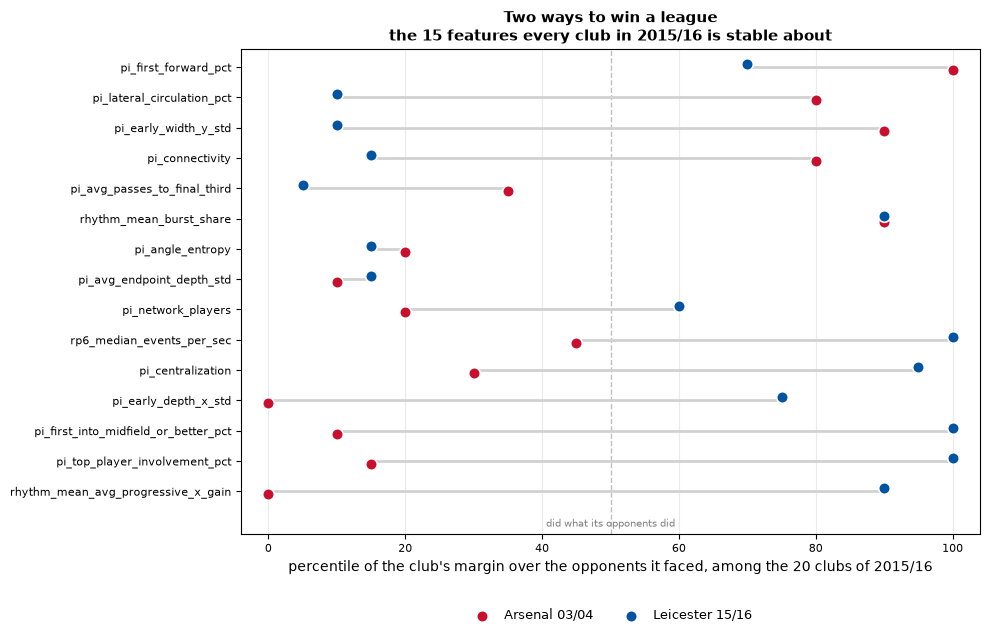

the spine, ordered as drawn:
                                      Arsenal 03/04  Leicester 15/16  gap
rhythm_mean_avg_progressive_x_gain              0.0             90.0 -3.8
pi_top_player_involvement_pct                  15.0            100.0 -3.3
pi_first_into_midfield_or_better_pct           10.0            100.0 -3.3
pi_early_depth_x_std                            0.0             75.0 -3.1
pi_centralization                              30.0             95.0 -1.8
rp6_median_events_per_sec                      45.0            100.0 -1.7
pi_network_players                             20.0             60.0 -0.5
pi_avg_endpoint_depth_std                      10.0             15.0 -0.1
pi_angle_entropy                               20.0             15.0  0.6
rhythm_mean_burst_share                        90.0             90.0  0.7
pi_avg_passes_to_final_third                   35.0              5.0  1.4
pi_connectivity                                80.0             15.0  2.2
pi_early_

In [3]:
CLUB_COLOR = {INVINCIBLES: "#c8102e", FOXES: "#0053a0"}   # as in 2b / 3b / 3c
LABEL = {INVINCIBLES: "Arsenal 03/04", FOXES: "Leicester 15/16"}

panel = champions.loc[spine].sort_values("gap")
y = np.arange(len(panel))

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.axvline(50, color="0.75", lw=1, ls="--", zorder=1)
ax.hlines(y, panel["Arsenal 03/04"], panel["Leicester 15/16"],
          color="0.82", lw=2, zorder=2)
# A constant vertical nudge, so a feature where both champions land on the same
# percentile still shows two marks instead of one hiding the other.
for club, nudge in ((INVINCIBLES, -0.10), (FOXES, 0.10)):
    ax.scatter(panel[LABEL[club]], y + nudge, s=70, color=CLUB_COLOR[club],
               zorder=3, edgecolor="white", linewidth=1.2, label=LABEL[club])

ax.set_yticks(y); ax.set_yticklabels(panel.index, fontsize=8)
ax.set_ylim(-1.4, len(panel) - 0.4)
ax.set_xlim(-4, 104)
ax.set_xlabel("percentile of the club's margin over the opponents it faced, "
              "among the 20 clubs of 2015/16")
ax.text(50, -1.25, "did what its opponents did", fontsize=7.5, color="0.5",
        ha="center", va="bottom")
ax.set_title("Two ways to win a league\n"
             f"the {len(spine)} features every club in 2015/16 is stable about",
             fontweight="bold", fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2,
          frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.25); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

print("the spine, ordered as drawn:")
print(panel.round(1).to_string())

## 2. What both champions did, whatever their style

The widest gaps are the story people expect. The narrow ones are more interesting, because
they are the candidates for something a title-winning side does regardless of how it plays.

In [4]:
shared = champions[champions["gap"].abs() < 0.35]
print("anchors where the two champions are within a third of a standard deviation:")
print(shared.round(1).to_string())

both_high = champions[(champions["Arsenal 03/04"] >= 70) & (champions["Leicester 15/16"] >= 70)]
both_low = champions[(champions["Arsenal 03/04"] <= 30) & (champions["Leicester 15/16"] <= 30)]
print(f"\nboth above the 70th percentile: {len(both_high)} anchors")
print(both_high.round(1).to_string())
print(f"\nboth below the 30th percentile: {len(both_low)} anchors")
print(both_low.round(1).to_string())

anchors where the two champions are within a third of a standard deviation:
                           Arsenal 03/04  Leicester 15/16  gap
pi_avg_endpoint_depth_std           10.0             15.0 -0.1
rhythm_median_gap_cv                95.0             90.0  0.2
rp6_final_third_entry_pct           50.0             65.0 -0.2
pi_forward_pass_pct                 90.0             70.0  0.3

both above the 70th percentile: 4 anchors
                         Arsenal 03/04  Leicester 15/16  gap
pi_first_forward_pct             100.0             70.0  3.5
rhythm_mean_burst_share           90.0             90.0  0.7
rhythm_median_gap_cv              95.0             90.0  0.2
pi_forward_pass_pct               90.0             70.0  0.3

both below the 30th percentile: 3 anchors
                           Arsenal 03/04  Leicester 15/16  gap
pi_angle_entropy                    20.0             15.0  0.6
pi_avg_endpoint_depth_std           10.0             15.0 -0.1
pi_first_long_pct            

## 3. How far apart, in a league's own units

A distance is only meaningful against the spread of the thing it is measured in. The twenty
clubs of 2015/16 supply that scale.

In [5]:
placed = margins.place(team_contrast(old, INVINCIBLES, anchors))["z"]
apart = float(np.sqrt(((placed - margins.z.loc[FOXES]) ** 2).sum()))

pairs = margins.distances.to_numpy()
off_diagonal = pairs[~np.eye(len(pairs), dtype=bool)]
print(f"Arsenal 03/04 to Leicester 15/16: {apart:.2f}")
print(f"2015/16 club-to-club, for scale: min {off_diagonal.min():.2f}, "
      f"median {np.median(off_diagonal):.2f}, max {off_diagonal.max():.2f}")
print(f"share of 2015/16 club pairs further apart than these two: "
      f"{(off_diagonal > apart).mean() * 100:.0f}%")

gaps = np.sqrt(((margins.z - placed) ** 2).sum(axis=1)).sort_values()
print(f"\nArsenal 03/04's nearest clubs in the 2015/16 field of margins:")
print(gaps.head(4).round(2).to_string())
print(f"\nLeicester's nearest:")
print(margins.neighbours(FOXES, 3).round(2).to_string())

Arsenal 03/04 to Leicester 15/16: 15.22
2015/16 club-to-club, for scale: min 5.03, median 9.47, max 17.43
share of 2015/16 club pairs further apart than these two: 4%

Arsenal 03/04's nearest clubs in the 2015/16 field of margins:
team
Arsenal              7.14
Chelsea              7.63
AFC Bournemouth      8.72
Tottenham Hotspur    9.09

Leicester's nearest:
Sunderland         6.89
Watford            7.46
West Ham United    7.98


## 4. The ledger for this pairing

The drift estimate is rebuilt with Leicester as the modern focal club, so the 2015/16 baseline
is Leicester's own opponents rather than Arsenal's. Every verdict below describes the **raw**
lens. The percentiles above are already corrected, so a bad verdict does not invalidate them.

It does raise a different risk. A large drift share means the two collections measure that
feature very differently, and the contrast cancels a difference in level but not a difference
in meaning. Those anchors deserve more suspicion, not less.

In [6]:
ledger = confound_ledger(old, INVINCIBLES, new, FOXES, anchors)
champions["verdict"] = ledger["verdict"]
champions["in_spine"] = champions.index.isin(spine)

print("verdicts across the 49 anchors, with Leicester as the modern focal club:")
print(ledger["verdict"].value_counts().to_string())

top = champions["gap"].abs().sort_values(ascending=False).head(12).index
print(f"\nof the twelve widest separations, how many rest on a drift-heavy anchor:")
print(champions.loc[top, "verdict"].value_counts().to_string())

verdicts across the 49 anchors, with Leicester as the modern focal club:
verdict
offset-dominated    30
clean                9
mixed                7
no-gap               3

of the twelve widest separations, how many rest on a drift-heavy anchor:
verdict
offset-dominated    9
mixed               2
no-gap              1


## 5. Frozen artifact

In [7]:
out = champions.rename_axis("feature").reset_index()
out.to_csv(FEATURES_DIR / "phase3d_champion_contrasts.csv", index=False)
print(f"wrote phase3d_champion_contrasts.csv ({len(out)} anchors, "
      f"{out['in_spine'].sum()} on the spine)")

wrote phase3d_champion_contrasts.csv (49 anchors, 15 on the spine)


## Summary — two champions, two opposite ways to beat a league

### The headline

Arsenal 2003/04 and Leicester 2015/16 sit **15.22 apart** in the field of margins. Only **4%
of the 190 club pairs inside the 2015/16 Premier League are further apart than that**. Two
teams that both won their league are close to the maximum distance a single league contains.

The comparison holds up because both are measured the same way, as what a club did *more or
less than the sides it was beating*. And on nearly every axis that separates them, the two
champions do not merely differ in degree. They sit on **opposite sides of their own
opponents**.

| anchor | Arsenal vs its 2003/04 opponents | Leicester vs its 2015/16 opponents |
|---|---|---|
| `pass_completion_pct` | **+9.4 pts** (77.9 v 68.5) | **−7.6 pts** (68.0 v 75.6) |
| `carries_per100pass` | **+9.5** (78.3 v 68.7) | **−4.4** (68.5 v 73.0) |
| `rp6_mean_start_x` | **−4.8 m** (33.1 v 37.9) | **+5.3 m** (39.8 v 34.5) |
| `rhythm_mean_avg_progressive_x_gain` | **−5.4 m** (22.6 v 27.9) | **+3.1 m** (27.0 v 23.9) |
| `pi_lateral_circulation_pct` | **+4.3 pts** (49.8 v 45.4) | **−5.7 pts** (42.8 v 48.5) |
| `avg_pass_length_m` | **−3.2 m** (21.6 v 24.8) | **+1.4 m** (23.7 v 22.3) |
| `pi_early_width_y_std` | **+0.9** (12.2 v 11.4) | **−1.0** (11.2 v 12.2) |
| `pi_top_player_involvement_pct` | **−0.6 pts** (11.9 v 12.5) | **+1.7 pts** (13.6 v 11.9) |

Not one of those eight rows shares a sign. This is a mirror, not a gradient.

### Arsenal 2003/04, in one description

Percentiles are against the twenty clubs of 2015/16, each measured as its own margin.

The Invincibles kept the ball better than anyone in this field manages against its opponents
(**100th percentile** on completion, 77.9% against their opponents' 68.5%), passed it
**shorter** than any of them (0th on pass length), and **carried** it more than any of them
(100th). They started their sustained possessions **deeper than any club here** (0th on
buildup start position, 33.1 m against 37.9 m), sent the first pass forward more than any
club here (100th), then declined to hurry: ground gained per possession sits at the **0th
percentile**, first pass reaching midifield or better at the 10th, early-depth variation at
the 0th. They spread the early build **wider** than their opponents (90th) and circulated
**laterally** more (80th).

Put together: take the ball deep, keep it, work it short and forward into feet, advance by
running with it through a wide and well-connected structure, and do not transit the pitch
quickly. Territory by accumulation.

### Leicester 2015/16, in one description

Almost the photographic negative. Leicester started possessions **higher than any club in its
own league** (100th, 39.8 m against its opponents' 34.5 m), gained more ground per possession
than nearly all of them (90th), got the first pass into midfield or beyond more than any of
them (100th), passed **longer** than its opponents (85th), and ran the sustained phases
**faster** than any club here (100th on sustained buildup tempo).

It paid for that in the places the possession game protects. Completion at the **15th
percentile**, 68.0% against opponents at 75.6%. Lateral circulation at the 10th. Early width
at the 5th, the narrowest margin in the field. Carrying at the 20th.

And it funnelled: **top-player involvement at the 100th percentile**, 13.6% against opponents'
11.9%. Leicester concentrated the ball through one man more than any club in this field, where
Arsenal deliberately did the opposite (15th percentile, *below* its own opponents). Given
Vardy and Mahrez, that is the counter-attack showing up as a network statistic.

### What both champions did anyway

Seven anchors put them on the same side. These are the candidates for something a
title-winning side does regardless of how it plays.

**Both above the 70th percentile.** `pi_first_forward_pct` (100th / 70th), `pi_forward_pass_pct`
(90th / 70th), `rhythm_mean_burst_share` (90th / 90th), `rhythm_median_gap_cv` (95th / 90th).
Both champions passed **forward** more than the teams they beat, played in **bursts** more,
and ran a **more irregular rhythm** than their opponents. The magnitudes are small in raw
terms (gap CV of 1.10 against 1.07 for both) but the league's spread on those axes is small
too, which is exactly what a percentile is for.

**Both below the 30th percentile.** `pi_angle_entropy` (20th / 15th), `pi_avg_endpoint_depth_std`
(10th / 15th), `pi_first_long_pct` (5th / 15th).

That first one closes a loop opened in Phase 3b. `pi_angle_entropy` was singled out as the
lowest-variance feature for both champions and called a universal identity axis. Phase 3c then
showed it barely separates them from the field in raw terms. Here it says something better:
**both champions passed at more structured angles than the teams they beat** (Arsenal 2.85
against 2.86, Leicester 2.84 against 2.87). Twelve years apart, playing opposite football,
both were more organised in passing geometry than their opposition. That is a claim the raw
lens could not have made and 3b's n=2 could not have supported.

`pi_first_long_pct` is the useful surprise. Even Leicester, whose passes were longer overall
than its opponents', did **not** launch the first pass of a possession long more often than
they did (50.6% against 51.9%). The directness lived in what happened after the first pass,
not in hitting it long.

### The spine, where the claim is safest

Restricted to the fifteen features every club in 2015/16 anchors on, the mean separation is
**2.11 sd**, larger than the 1.87 across all 49. The disagreement is not an artifact of
including marginal features. It is strongest on the axes the league is most consistent about.

The spine ordering also states the split cleanly. Leicester leads on ground gained, top-player
concentration, first pass into midfield, early-depth variation, centralization and tempo.
Arsenal leads on forward first pass, lateral circulation, early width, connectivity and passes
into the final third.

### What this notebook cannot claim

**That era and club are separable.** At n = 2 teams they are the same variable. Nothing here
distinguishes "Leicester played differently from Arsenal" from "2015/16 football was different
from 2003/04 football". 3d-i is the notebook with a shared before, and its answer was that
Arsenal's own margin barely moved across the twelve years, which argues the difference here is
mostly Leicester rather than the era. That is an argument, not a proof.

**That the placement is symmetric.** Leicester is native to this field, measured against
nineteen clubs it actually played. Arsenal 2003/04 is placed into it, measured against clubs
it never met in a season collected twelve years later.

**That every headline rests on clean ground.** Of the twelve widest separations, **nine sit on
anchors the ledger calls offset-dominated** in the raw lens. The percentiles quoted here are
already corrected, so that is not an error in them. It is a warning that those are the
features the two collections measure most differently, and the contrast cancels a difference
in level but not a difference in meaning. The safest claims in this notebook are the ones
resting on `pi_first_forward_pct` and `pi_angle_entropy`, whose drift shares are low.

### Where this leaves Phase 3

Phase 3 set out to compare the Invincibles and Leicester. It ends with a sharper result than a
comparison. **A champion's margin over the teams it beats is a stable, measurable object**,
these two champions built theirs in nearly opposite ways, and the handful of things they share
are the more interesting output, because they survived twelve years and two opposite
philosophies. That shared set, forward passing, burst rhythm, irregular tempo and structured
passing angles, is the first cross-era candidate this project has for what winning looks like
independent of style.